<a href="https://colab.research.google.com/github/HamzaFarooq2002/AF3005_ProgrammingForFinance_FinTech/blob/main/Credit_Score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# We need one library that doesn't come with Colab by default
# imbalanced-learn handles SMOTE (balancing our dataset)
# Everything else (pandas, numpy, sklearn, xgboost) is already in Colab

!pip install imbalanced-learn xgboost --quiet

print("Installation complete")

Installation complete


In [2]:
# Think of imports like opening your toolbox before starting work
# Each line brings in a specific tool we'll use later

import pandas as pd                          # for working with tables (DataFrames)
import numpy as np                           # for math and numbers
import matplotlib.pyplot as plt              # for drawing charts
import seaborn as sns                        # for prettier charts
import pickle                                # for saving our trained model to a file

from sklearn.model_selection import train_test_split   # splits data into train/test
from sklearn.preprocessing import MinMaxScaler         # scales numbers to 0-1 range
from sklearn.metrics import (
    classification_report,                   # shows precision, recall, f1
    roc_auc_score,                           # our main evaluation metric
    confusion_matrix,                        # shows true/false positives
    ConfusionMatrixDisplay                   # draws the confusion matrix
)

from imblearn.over_sampling import SMOTE     # balances unequal class distribution
from xgboost import XGBClassifier           # our ML model

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [3]:
merchant_df = pd.read_csv('superbazaar_merchant_synthetic.csv')

In [4]:
print("=" * 50)
print("MERCHANT DATASET")
print("=" * 50)
print(f"Rows: {len(merchant_df)}")
print(f"Columns: {list(merchant_df.columns)}")
print("\nFirst 3 rows:")
print(merchant_df.head(3))

MERCHANT DATASET
Rows: 1000
Columns: ['account_age_days', 'monthly_revenue', 'monthly_expenses', 'net_profit', 'store_rating', 'is_verified', 'cancellation_rate', 'overdue_installments', 'is_default']

First 3 rows:
   account_age_days  monthly_revenue  monthly_expenses  net_profit  \
0              1156           420965            271025      149940   
1               890            53754             30827       22927   
2              1160           601332            436924      164408   

   store_rating  is_verified  cancellation_rate  overdue_installments  \
0          3.13            1              0.454                    10   
1          1.77            1              0.413                     7   
2          2.08            1              0.518                     9   

   is_default  
0           0  
1           1  
2           1  


In [5]:
customer_df = pd.read_csv('superbazaar_customer_synthetic.csv')

In [6]:
print("\n" + "=" * 50)
print("CUSTOMER DATASET")
print("=" * 50)
print(f"Rows: {len(customer_df)}")
print(f"Columns: {list(customer_df.columns)}")
print("\nFirst 3 rows:")
print(customer_df.head(3))


CUSTOMER DATASET
Rows: 1000
Columns: ['account_age_days', 'wallet_balance', 'avg_basket_size', 'failed_payments', 'payment_method_score', 'cancellation_rate', 'overdue_installments', 'kyc_verified', 'is_default']

First 3 rows:
   account_age_days  wallet_balance  avg_basket_size  failed_payments  \
0                17            9867            12472                5   
1               553             559            15805                1   
2               477           49307            11293                6   

   payment_method_score  cancellation_rate  overdue_installments  \
0                     1              0.300                     4   
1                     1              0.605                     0   
2                     3              0.486                     1   

   kyc_verified  is_default  
0             0           1  
1             0           0  
2             1           0  


In [7]:
print("=" * 50)
print("MERCHANT — Basic Statistics")
print("=" * 50)
print(merchant_df.describe().round(2))

MERCHANT — Basic Statistics
       account_age_days  monthly_revenue  monthly_expenses  net_profit  \
count           1000.00          1000.00           1000.00     1000.00   
mean             634.19        337125.01         194520.32   142604.68   
std              344.79        236932.05         142495.95   108498.52   
min               30.00         11700.00           5231.00     4059.00   
25%              329.50        130218.25          70434.25    51904.25   
50%              670.50        270376.00         150987.00   107588.00   
75%              924.25        551599.75         311062.00   217187.25   
max             1199.00        799122.00         587790.00   467992.00   

       store_rating  is_verified  cancellation_rate  overdue_installments  \
count       1000.00      1000.00            1000.00               1000.00   
mean           3.20         0.71               0.29                  5.07   
std            1.00         0.45               0.18                  3.23 

In [8]:
print(merchant_df.isnull().sum())

account_age_days        0
monthly_revenue         0
monthly_expenses        0
net_profit              0
store_rating            0
is_verified             0
cancellation_rate       0
overdue_installments    0
is_default              0
dtype: int64


In [9]:
print("\n" + "=" * 50)
print("CUSTOMER — Basic Statistics")
print("=" * 50)
print(customer_df.describe().round(2))


CUSTOMER — Basic Statistics
       account_age_days  wallet_balance  avg_basket_size  failed_payments  \
count           1000.00         1000.00          1000.00          1000.00   
mean             513.24        18056.17         12901.28             3.88   
std              279.83        14843.70          7067.12             2.62   
min               10.00            8.00           516.00             0.00   
25%              270.50         5508.50          6936.25             2.00   
50%              522.50        12139.50         12769.00             4.00   
75%              756.50        30252.25         19023.00             6.00   
max              999.00        49985.00         24991.00             8.00   

       payment_method_score  cancellation_rate  overdue_installments  \
count               1000.00            1000.00               1000.00   
mean                   2.17               0.35                  4.01   
std                    1.09               0.21               

In [10]:
print(customer_df.isnull().sum())

account_age_days        0
wallet_balance          0
avg_basket_size         0
failed_payments         0
payment_method_score    0
cancellation_rate       0
overdue_installments    0
kyc_verified            0
is_default              0
dtype: int64


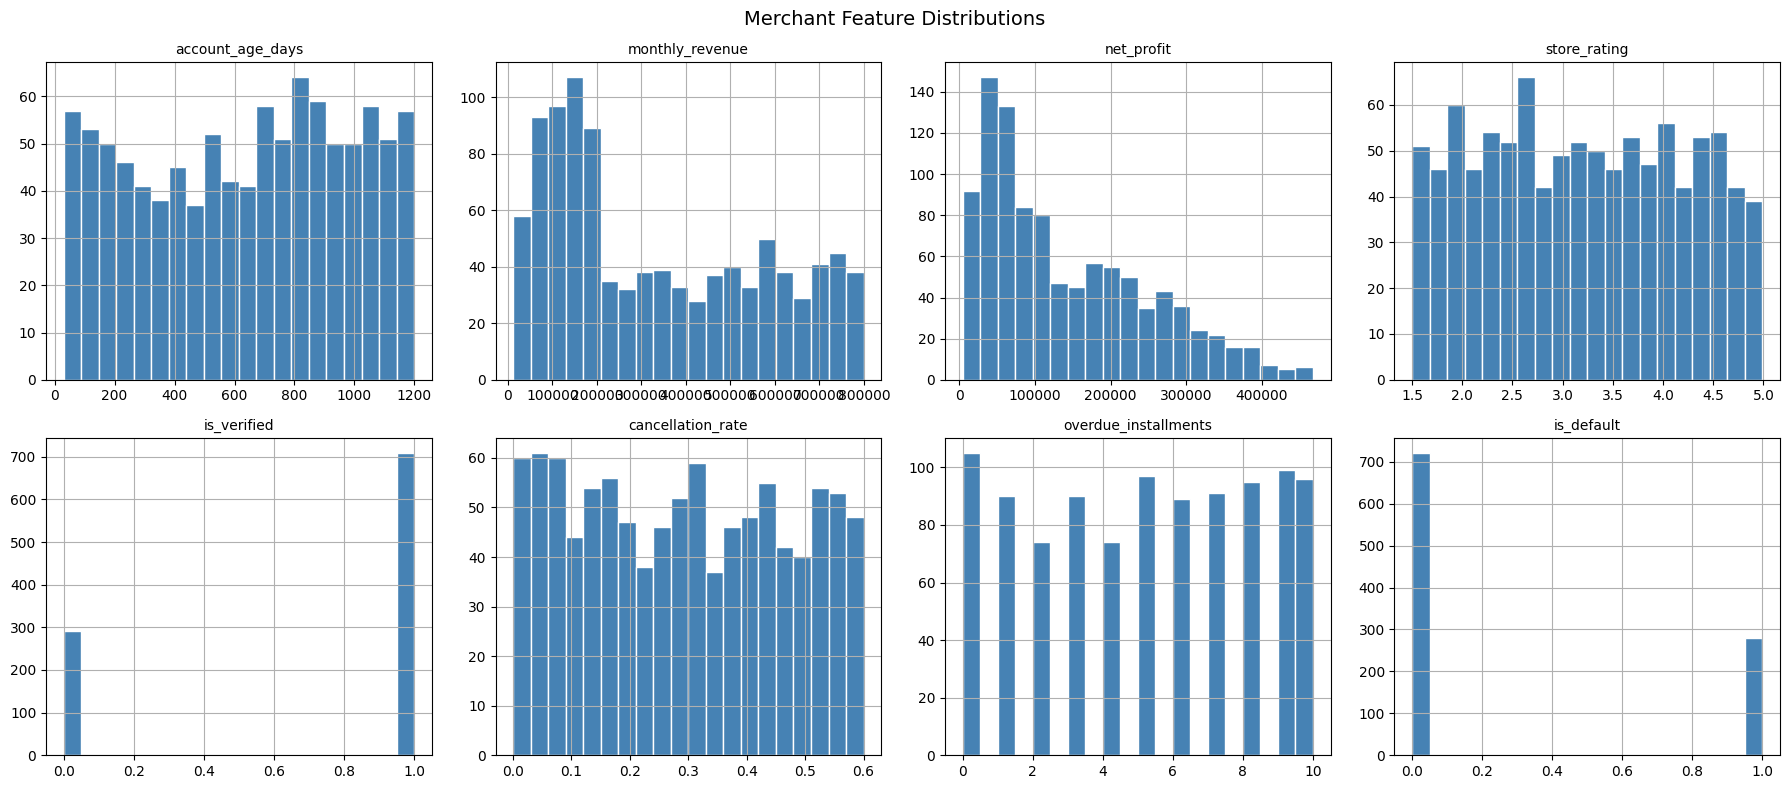

In [11]:
# Charts help you SEE the data before training
# This is important — you want to confirm the data makes sense visually

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Merchant Feature Distributions', fontsize=14)

merchant_features = ['account_age_days', 'monthly_revenue', 'net_profit',
                     'store_rating', 'is_verified', 'cancellation_rate',
                     'overdue_installments', 'is_default']

for i, col in enumerate(merchant_features):
    merchant_df[col].hist(ax=axes[i//4][i%4], bins=20, color='steelblue', edgecolor='white')
    axes[i//4][i%4].set_title(col, fontsize=10)
    axes[i//4][i%4].set_xlabel('')

plt.tight_layout()
plt.show()


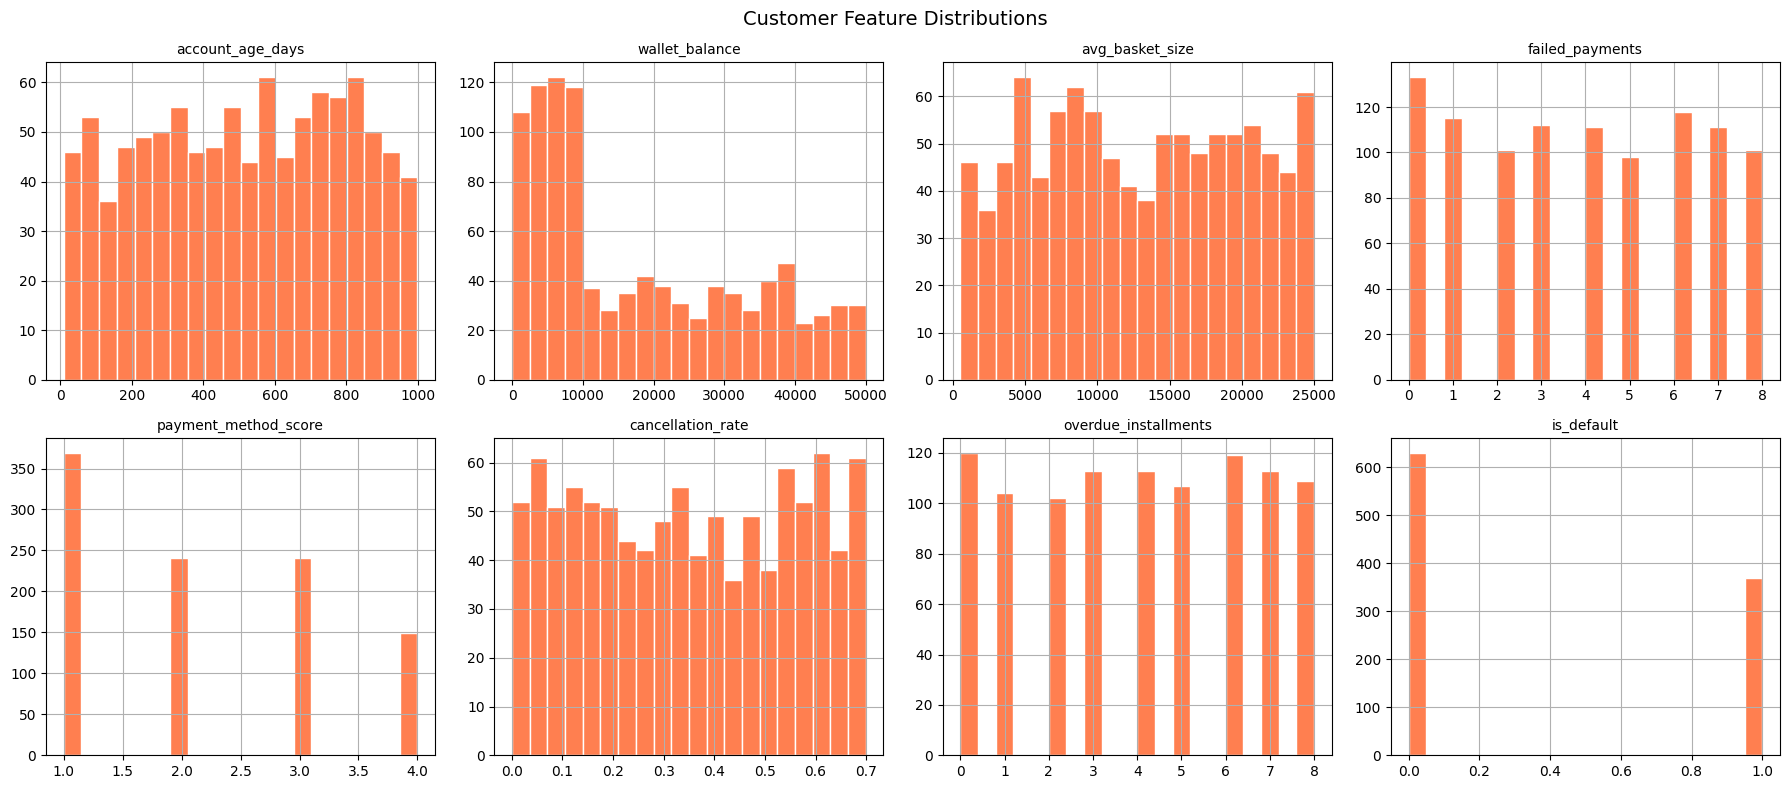

✅ Charts generated — review them above


In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Customer Feature Distributions', fontsize=14)

customer_features_plot = ['account_age_days', 'wallet_balance', 'avg_basket_size',
                          'failed_payments', 'payment_method_score', 'cancellation_rate',
                          'overdue_installments', 'is_default']

for i, col in enumerate(customer_features_plot):
    customer_df[col].hist(ax=axes[i//4][i%4], bins=20, color='coral', edgecolor='white')
    axes[i//4][i%4].set_title(col, fontsize=10)

plt.tight_layout()
plt.show()

print("✅ Charts generated — review them above")

In [13]:
# Correlation tells us if two features are measuring the same thing
# If two features are highly correlated (above 0.85), one is redundant
# We drop the redundant one — it wastes the model's attention

print("MERCHANT Correlation Matrix:")
merchant_corr = merchant_df.drop(columns=['is_default']).corr().round(2)
print(merchant_corr)

MERCHANT Correlation Matrix:
                      account_age_days  monthly_revenue  monthly_expenses  \
account_age_days                  1.00             0.05              0.05   
monthly_revenue                   0.05             1.00              0.96   
monthly_expenses                  0.05             0.96              1.00   
net_profit                        0.03             0.93              0.78   
store_rating                     -0.02             0.06              0.05   
is_verified                       0.02             0.62              0.60   
cancellation_rate                -0.01            -0.02             -0.02   
overdue_installments             -0.04            -0.05             -0.03   

                      net_profit  store_rating  is_verified  \
account_age_days            0.03         -0.02         0.02   
monthly_revenue             0.93          0.06         0.62   
monthly_expenses            0.78          0.05         0.60   
net_profit               

In [14]:
print("\nCUSTOMER Correlation Matrix:")
customer_corr = customer_df.drop(columns=['is_default']).corr().round(2)
print(customer_corr)


CUSTOMER Correlation Matrix:
                      account_age_days  wallet_balance  avg_basket_size  \
account_age_days                  1.00            0.02             0.04   
wallet_balance                    0.02            1.00             0.03   
avg_basket_size                   0.04            0.03             1.00   
failed_payments                   0.07            0.03             0.02   
payment_method_score              0.00           -0.03             0.02   
cancellation_rate                -0.02            0.01            -0.04   
overdue_installments             -0.01            0.00             0.01   
kyc_verified                     -0.00            0.63             0.06   

                      failed_payments  payment_method_score  \
account_age_days                 0.07                  0.00   
wallet_balance                   0.03                 -0.03   
avg_basket_size                  0.02                  0.02   
failed_payments                  1.00     

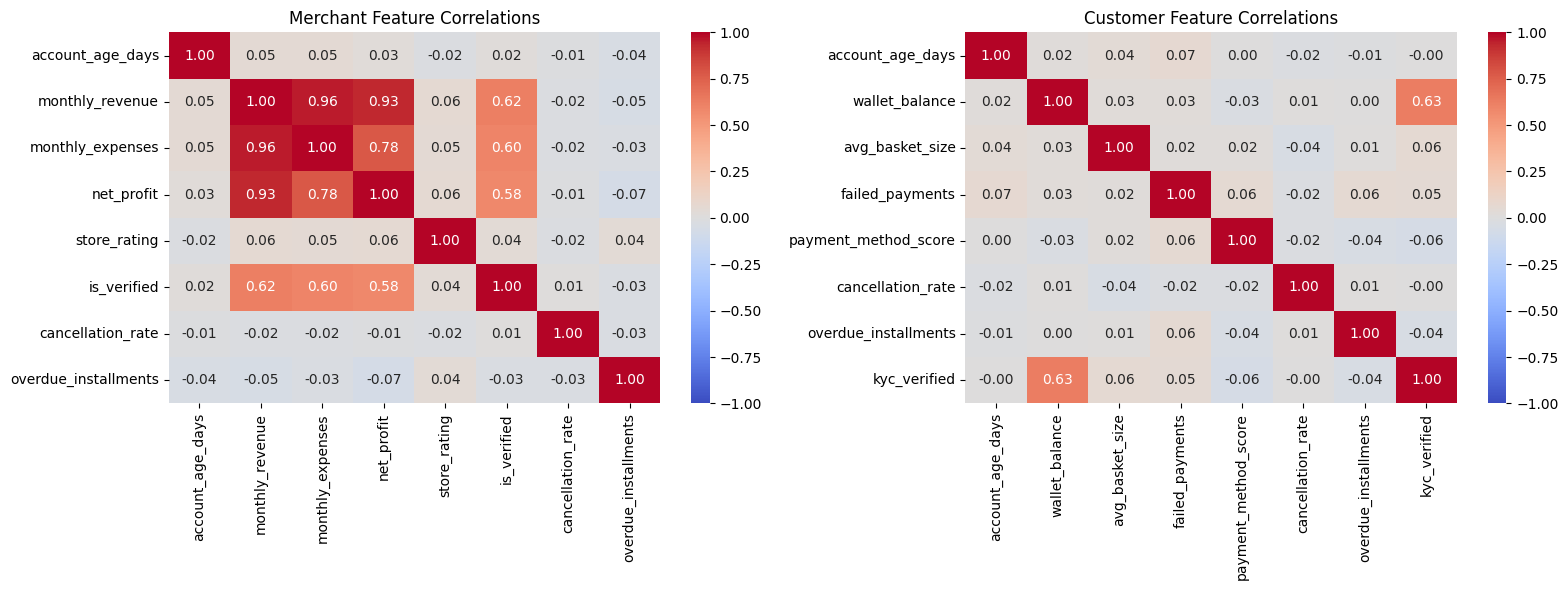

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(merchant_corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax1, vmin=-1, vmax=1)
ax1.set_title('Merchant Feature Correlations')

sns.heatmap(customer_corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax2, vmin=-1, vmax=1)
ax2.set_title('Customer Feature Correlations')

plt.tight_layout()
plt.show()

In [16]:
# Flag anything above 0.85
print("\n⚠️  HIGH CORRELATIONS (above 0.85) — candidates for removal:")
for df_name, corr_df in [("Merchant", merchant_corr), ("Customer", customer_corr)]:
    found = False
    for col in corr_df.columns:
        for row in corr_df.index:
            if col != row and abs(corr_df.loc[row, col]) > 0.85:
                print(f"  {df_name}: {row} ↔ {col} = {corr_df.loc[row, col]}")
                found = True
    if not found:
        print(f"  {df_name}: None found ✅")


⚠️  HIGH CORRELATIONS (above 0.85) — candidates for removal:
  Merchant: monthly_expenses ↔ monthly_revenue = 0.96
  Merchant: net_profit ↔ monthly_revenue = 0.93
  Merchant: monthly_revenue ↔ monthly_expenses = 0.96
  Merchant: monthly_revenue ↔ net_profit = 0.93
  Customer: None found ✅


In [17]:
# X = features (what the model learns FROM)
# y = target (what the model learns TO PREDICT)
# is_default is always y — never X

# MERCHANT
X_merchant = merchant_df.drop(columns=['is_default'])   # all columns except target
y_merchant = merchant_df['is_default']                  # only the target column


In [18]:
print("MERCHANT")
print(f"  X shape (features): {X_merchant.shape}  ← 1000 rows, 8 features")
print(f"  y shape (target):   {y_merchant.shape}   ← 1000 labels")

MERCHANT
  X shape (features): (1000, 8)  ← 1000 rows, 8 features
  y shape (target):   (1000,)   ← 1000 labels


In [19]:
# CUSTOMER
X_customer = customer_df.drop(columns=['is_default'])
y_customer = customer_df['is_default']

In [20]:
print("\nCUSTOMER")
print(f"  X shape (features): {X_customer.shape}  ← 1000 rows, 8 features")
print(f"  y shape (target):   {y_customer.shape}   ← 1000 labels")


CUSTOMER
  X shape (features): (1000, 8)  ← 1000 rows, 8 features
  y shape (target):   (1000,)   ← 1000 labels


In [21]:
print("\n✅ Features and target separated")



✅ Features and target separated


In [22]:
# We split data into two parts:
# Training set (80%) — model learns from this
# Test set (20%)     — we use this to check if the model actually learned
#
# CRITICAL RULE: Test set is never touched until final evaluation
# Think of it as the exam — the model studies on training data, tested on test data

X_merch_train, X_merch_test, y_merch_train, y_merch_test = train_test_split(
    X_merchant, y_merchant,
    test_size=0.2,          # 20% goes to test
    random_state=42,        # ensures same split every time you run
    stratify=y_merchant     # keeps default rate equal in both splits
)

X_cust_train, X_cust_test, y_cust_train, y_cust_test = train_test_split(
    X_customer, y_customer,
    test_size=0.2,
    random_state=42,
    stratify=y_customer
)

print("MERCHANT SPLIT")
print(f"  Training rows: {len(X_merch_train)} | Test rows: {len(X_merch_test)}")
print(f"  Training defaults: {y_merch_train.sum()} | Test defaults: {y_merch_test.sum()}")

print("\nCUSTOMER SPLIT")
print(f"  Training rows: {len(X_cust_train)} | Test rows: {len(X_cust_test)}")
print(f"  Training defaults: {y_cust_train.sum()} | Test defaults: {y_cust_test.sum()}")

print("\n✅ Data split complete")

MERCHANT SPLIT
  Training rows: 800 | Test rows: 200
  Training defaults: 223 | Test defaults: 56

CUSTOMER SPLIT
  Training rows: 800 | Test rows: 200
  Training defaults: 296 | Test defaults: 74

✅ Data split complete


In [23]:
# MinMaxScaler converts all numbers to a 0–1 range
# Example: account_age_days of 500 in a range of 30–1200 becomes ~0.40
#
# WHY: Prevents features with large numbers (monthly_revenue = 500,000)
# from overpowering features with small numbers (store_rating = 4.2)
#
# IMPORTANT: Fit the scaler on TRAINING data only
# Then use it to transform BOTH train and test
# Never fit on test data — that would be cheating

scaler_merchant = MinMaxScaler()
scaler_customer = MinMaxScaler()

# fit_transform: learns the min/max from training data AND transforms it
X_merch_train_scaled = scaler_merchant.fit_transform(X_merch_train)

# transform only: uses the min/max already learned — does NOT relearn
X_merch_test_scaled  = scaler_merchant.transform(X_merch_test)

X_cust_train_scaled  = scaler_customer.fit_transform(X_cust_train)
X_cust_test_scaled   = scaler_customer.transform(X_cust_test)

print("Before scaling — merchant monthly_revenue sample:")
print(X_merch_train['monthly_revenue'].head(3).values)

print("\nAfter scaling — same column:")
print(X_merch_train_scaled[:3, list(X_merchant.columns).index('monthly_revenue')])

print("\n✅ All features scaled to [0, 1] range")

Before scaling — merchant monthly_revenue sample:
[501558 786983 239139]

After scaling — same column:
[0.62210352 0.98458387 0.28884004]

✅ All features scaled to [0, 1] range


In [24]:
# SMOTE = Synthetic Minority Oversampling Technique
# Problem: if only 20% of rows are defaults, model learns to ignore them
# SMOTE creates synthetic (fake but realistic) default examples
# until both classes are equal
#
# RULE: SMOTE only on TRAINING data — NEVER on test data
# If you SMOTE before splitting, your test data gets contaminated

smote = SMOTE(random_state=42)

X_merch_train_sm, y_merch_train_sm = smote.fit_resample(X_merch_train_scaled, y_merch_train)
X_cust_train_sm,  y_cust_train_sm  = smote.fit_resample(X_cust_train_scaled,  y_cust_train)

print("MERCHANT — Before and After SMOTE")
print(f"  Before: {dict(zip(*np.unique(y_merch_train, return_counts=True)))}")
print(f"  After:  {dict(zip(*np.unique(y_merch_train_sm, return_counts=True)))}")

print("\nCUSTOMER — Before and After SMOTE")
print(f"  Before: {dict(zip(*np.unique(y_cust_train, return_counts=True)))}")
print(f"  After:  {dict(zip(*np.unique(y_cust_train_sm, return_counts=True)))}")

print("\n✅ Classes balanced — model will learn both equally")

MERCHANT — Before and After SMOTE
  Before: {np.int64(0): np.int64(577), np.int64(1): np.int64(223)}
  After:  {np.int64(0): np.int64(577), np.int64(1): np.int64(577)}

CUSTOMER — Before and After SMOTE
  Before: {np.int64(0): np.int64(504), np.int64(1): np.int64(296)}
  After:  {np.int64(0): np.int64(504), np.int64(1): np.int64(504)}

✅ Classes balanced — model will learn both equally


In [25]:
# XGBoost is a decision tree algorithm that builds many trees
# and combines them to make a final prediction
#
# Key parameters:
# n_estimators    = how many trees to build (more = better but slower)
# max_depth       = how deep each tree goes (deeper = more complex)
# learning_rate   = how fast it learns (lower = more careful)
# use_label_encoder & eval_metric = just settings to avoid warnings

print("Training Merchant model...")
merchant_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
merchant_model.fit(X_merch_train_sm, y_merch_train_sm)
print("✅ Merchant model trained")

print("\nTraining Customer model...")
customer_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
customer_model.fit(X_cust_train_sm, y_cust_train_sm)
print("✅ Customer model trained")

Training Merchant model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:36:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Merchant model trained

Training Customer model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:36:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Customer model trained



MERCHANT MODEL RESULTS

AUC-ROC Score: 0.9926  🟢 Excellent

Classification Report:
              precision    recall  f1-score   support

  No Default       0.97      0.99      0.98       144
     Default       0.96      0.93      0.95        56

    accuracy                           0.97       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.97      0.97       200



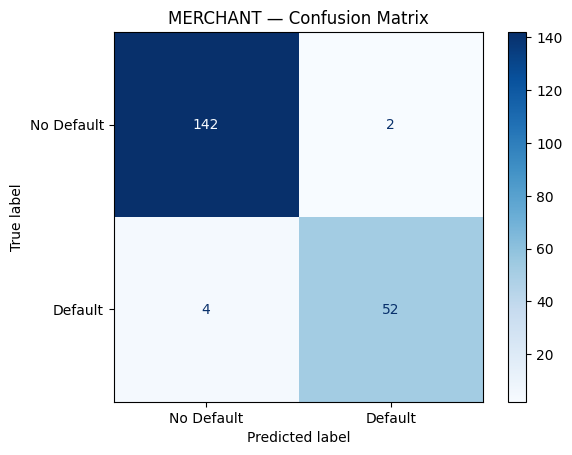


CUSTOMER MODEL RESULTS

AUC-ROC Score: 0.9989  🟢 Excellent

Classification Report:
              precision    recall  f1-score   support

  No Default       0.98      1.00      0.99       126
     Default       1.00      0.97      0.99        74

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



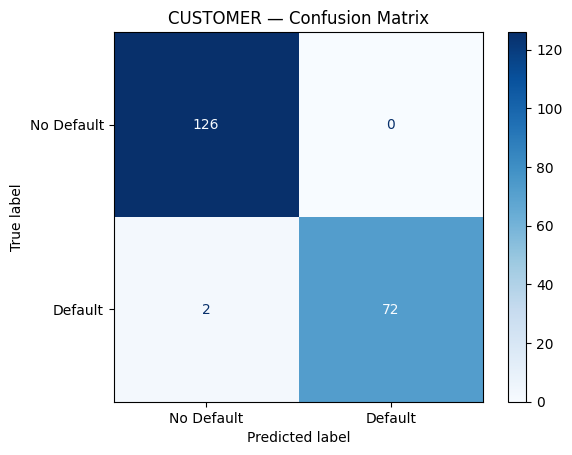

In [26]:
# Now we test on the 20% holdout data the model has NEVER seen
# AUC-ROC: our main metric
#   > 0.80 = solid model
#   > 0.75 = acceptable for MVP
#   < 0.70 = needs improvement

def evaluate_model(model, X_test, y_test, name):
    print(f"\n{'='*50}")
    print(f"{name} MODEL RESULTS")
    print(f"{'='*50}")

    # Get predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # probability of default

    # AUC-ROC score
    auc = roc_auc_score(y_test, y_prob)
    print(f"\nAUC-ROC Score: {auc:.4f}", end="  ")
    if auc >= 0.80:
        print("🟢 Excellent")
    elif auc >= 0.75:
        print("🟡 Good")
    else:
        print("🔴 Needs improvement")

    # Detailed report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred,
                                 target_names=['No Default', 'Default']))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Default', 'Default'])
    disp.plot(cmap='Blues')
    plt.title(f'{name} — Confusion Matrix')
    plt.show()

    return auc

merch_auc = evaluate_model(merchant_model, X_merch_test_scaled, y_merch_test, "MERCHANT")
cust_auc  = evaluate_model(customer_model, X_cust_test_scaled,  y_cust_test,  "CUSTOMER")

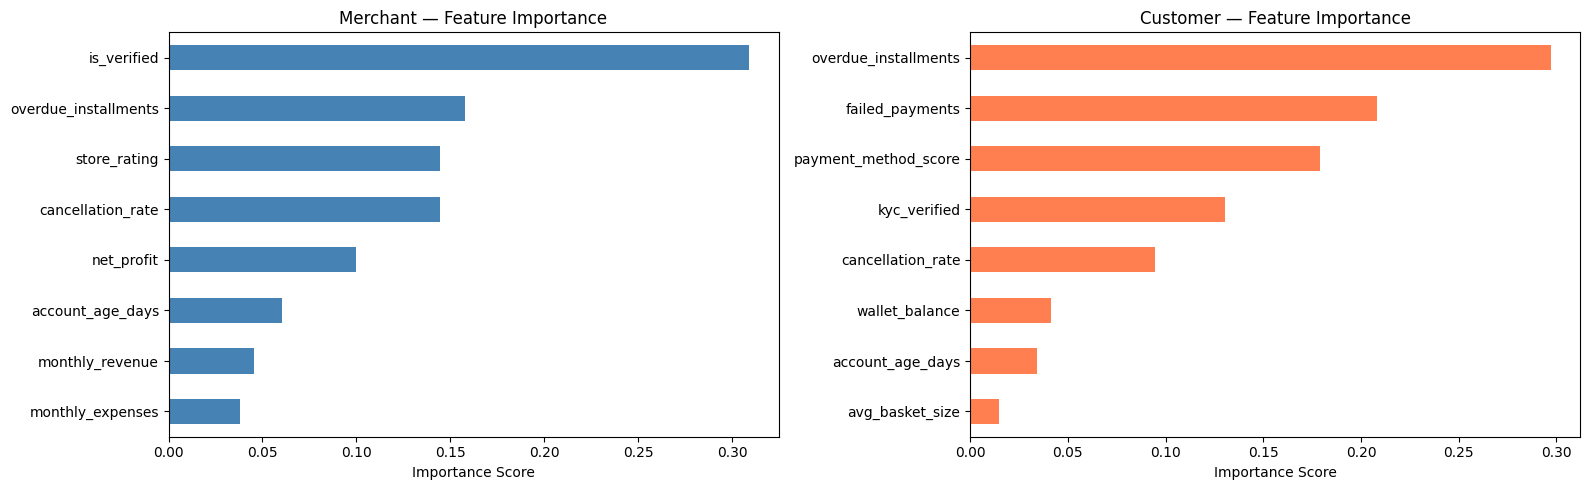

Most important merchant feature: is_verified
Most important customer feature: overdue_installments


In [27]:
# This shows WHICH features the model relied on most
# If overdue_installments is #1, that makes intuitive sense — good sign
# If something random is #1, that's a red flag

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Merchant
merch_importance = pd.Series(
    merchant_model.feature_importances_,
    index=X_merchant.columns
).sort_values(ascending=True)

merch_importance.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Merchant — Feature Importance')
ax1.set_xlabel('Importance Score')

# Customer
cust_importance = pd.Series(
    customer_model.feature_importances_,
    index=X_customer.columns
).sort_values(ascending=True)

cust_importance.plot(kind='barh', ax=ax2, color='coral')
ax2.set_title('Customer — Feature Importance')
ax2.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print("Most important merchant feature:", merch_importance.idxmax())
print("Most important customer feature:", cust_importance.idxmax())

In [29]:
import pickle
import json
from google.colab import files

# 1. Save the Models using pickle
with open('merchant_model.pkl', 'wb') as f:
    pickle.dump(merchant_model, f)
with open('customer_model.pkl', 'wb') as f:
    pickle.dump(customer_model, f)

# 2. Save the Scalers using pickle
with open('merchant_scaler.pkl', 'wb') as f:
    pickle.dump(scaler_merchant, f)
with open('customer_scaler.pkl', 'wb') as f:
    pickle.dump(scaler_customer, f)

# 3. Save the Feature Names using json
with open('merchant_features.json', 'w') as f:
    json.dump(list(X_merchant.columns), f)
with open('customer_features.json', 'w') as f:
    json.dump(list(X_customer.columns), f)

print("✅ All files saved to disk. Starting download...")

# 4. Download all 6 files
files.download('merchant_model.pkl')
files.download('customer_model.pkl')
files.download('merchant_scaler.pkl')
files.download('customer_scaler.pkl')
files.download('merchant_features.json')
files.download('customer_features.json')

print("✅ All files sent to browser — save them somewhere safe")
print("   You will need all 6 files for Phase 4 (FastAPI)")

✅ All files saved to disk. Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files sent to browser — save them somewhere safe
   You will need all 6 files for Phase 4 (FastAPI)
